In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
datos_arbolado= pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


In [4]:
datos_arbolado.info()
print(datos_arbolado['nombre_cientifico'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

### Analisar si hay relacion entre diametro y ancho acera

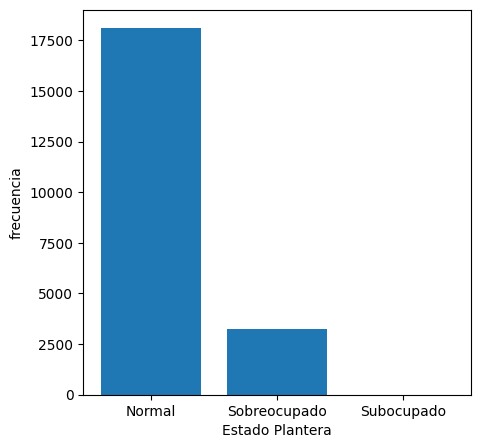

In [5]:
datos_ficus=datos_arbolado[datos_arbolado['nombre_cientifico']=='Ficus benjamina']

estado= datos_ficus['estado_plantera'].value_counts()

mapa_labels = {
    0: 'Vacío',
    1: 'Subocupado',
    2: 'Normal',
    3: 'Sobreocupado'
}

estado = estado.rename(mapa_labels)

plt.figure(figsize=(5,5))
plt.bar(estado.index,estado.values)
plt.xlabel('Estado Plantera')
plt.ylabel('frecuencia')
plt.show()

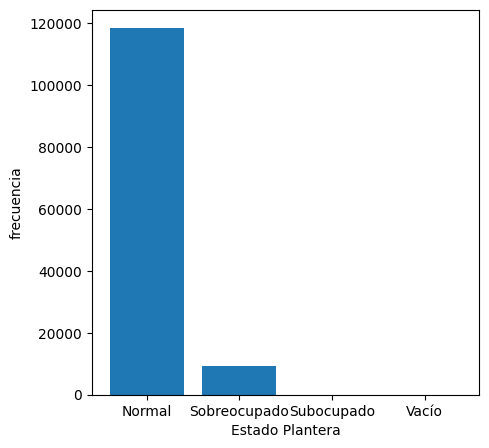

In [6]:
datos_ficus=datos_arbolado[datos_arbolado['nombre_cientifico']=='Fraxinus pennsylvanica']

estado= datos_ficus['estado_plantera'].value_counts()

mapa_labels = {
    0: 'Vacío',
    1: 'Subocupado',
    2: 'Normal',
    3: 'Sobreocupado'
}

estado = estado.rename(mapa_labels)

plt.figure(figsize=(5,5))
plt.bar(estado.index,estado.values)
plt.xlabel('Estado Plantera')
plt.ylabel('frecuencia')
plt.show()

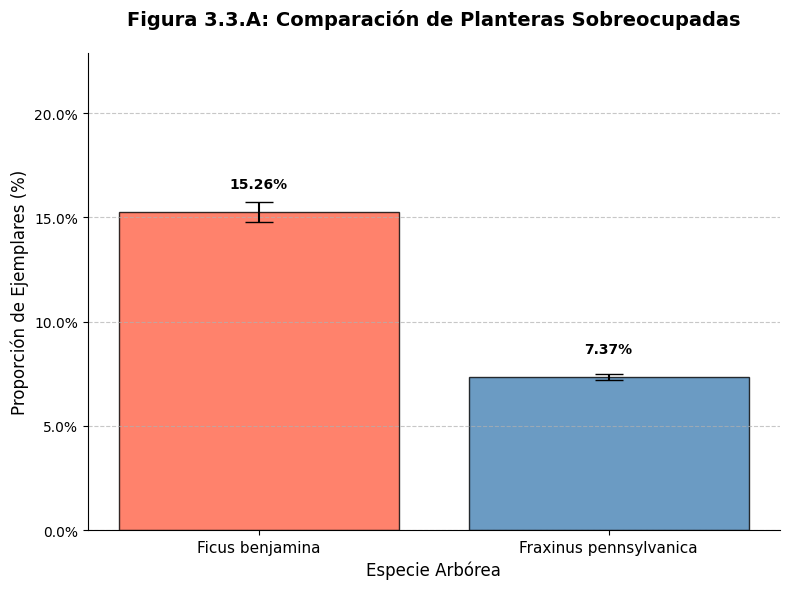

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# --- 1. Datos de la Hipótesis ---
# Grupo 1: Ficus benjamina
x_ficus = 3263
n_ficus = 21379

# Grupo 2: Fraxinus pennsylvanica
x_fraxinus = 9431
n_fraxinus = 127973

# --- 2. Cálculos Estadísticos ---
# Calcular proporciones
p_ficus = x_ficus / n_ficus
p_fraxinus = x_fraxinus / n_fraxinus

# Calcular el Margen de Error (ME) para 95% CI
# ME = z * sqrt(p*(1-p)/n)
z = 1.96  # z-score para 95% CI

se_ficus = np.sqrt(p_ficus * (1 - p_ficus) / n_ficus)
me_ficus = z * se_ficus

se_fraxinus = np.sqrt(p_fraxinus * (1 - p_fraxinus) / n_fraxinus)
me_fraxinus = z * se_fraxinus

# Preparar datos para el gráfico
especies = ['Ficus benjamina', 'Fraxinus pennsylvanica']
proporciones = [p_ficus, p_fraxinus]
errores = [me_ficus, me_fraxinus]

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(8, 6))

# Crear las barras
bars = plt.bar(especies, proporciones, 
               yerr=errores, 
               capsize=10,  # Añade "bigotes" a las barras de error
               color=['#FF6347', '#4682B4'],  # Rojo (Ficus), Azul (Fraxinus)
               alpha=0.8,
               edgecolor='black')

# --- 4. Formato y Etiquetas ---
# Formatear el eje Y como porcentaje
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Ajustar límites del eje Y para mejor visualización
plt.ylim(0, max(proporciones) * 1.5)

# Añadir etiquetas de texto (porcentaje) sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, 
             yval + 0.01,  # Posición vertical (un poco encima de la barra)
             f'{yval:.2%}', 
             ha='center', 
             va='bottom',
             fontweight='bold')

# Títulos y etiquetas de ejes
plt.title('Figura 3.3.A: Comparación de Planteras Sobreocupadas', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Proporción de Ejemplares (%)', fontsize=12)
plt.xlabel('Especie Arbórea', fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

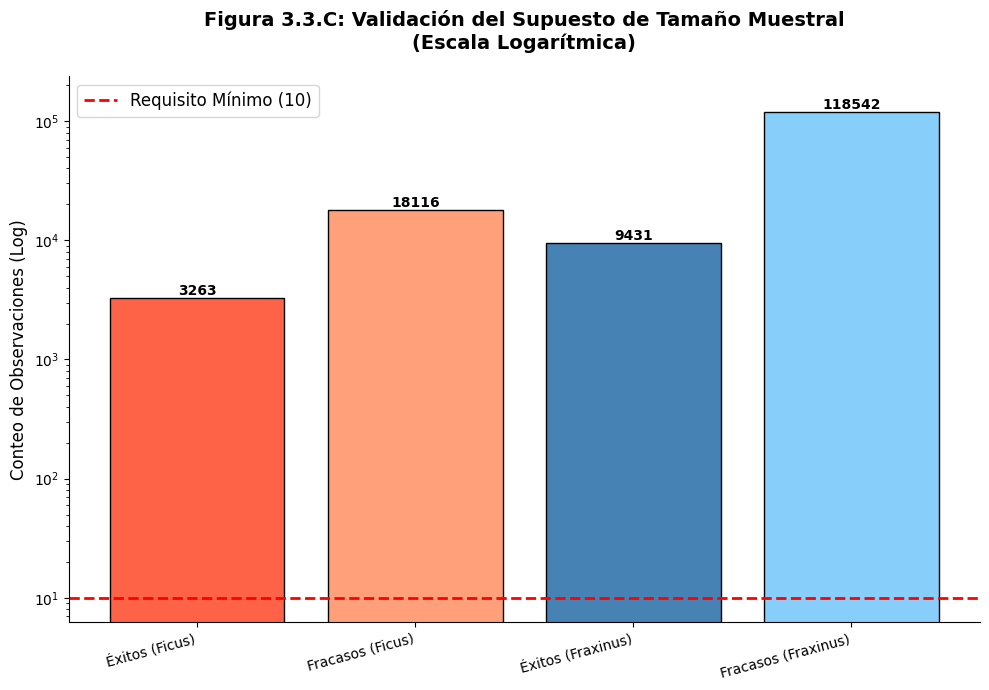

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Datos de los conteos (Éxitos/Fracasos) ---
# Grupo 1: Ficus
x_ficus = 3263
n_ficus = 21379
f_ficus = n_ficus - x_ficus # Fracasos Ficus

# Grupo 2: Fraxinus
x_fraxinus = 9431
n_fraxinus = 127973
f_fraxinus = n_fraxinus - x_fraxinus # Fracasos Fraxinus

# Requisito mínimo
requisito = 10

# --- 2. Preparar datos para el gráfico ---
etiquetas = [
    'Éxitos (Ficus)', 
    'Fracasos (Ficus)', 
    'Éxitos (Fraxinus)', 
    'Fracasos (Fraxinus)'
]
valores = [x_ficus, f_ficus, x_fraxinus, f_fraxinus]
colores = ['#FF6347', '#FFA07A', '#4682B4', '#87CEFA']

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(10, 7))

# Crear las barras
bars = plt.bar(etiquetas, valores, color=colores, edgecolor='black')

# !! --- USAR ESCALA LOGARÍTMICA --- !!
# Esto es esencial para poder ver la línea de 10
plt.yscale('log')

# Añadir la línea del requisito
plt.axhline(y=requisito, color='red', linestyle='--', linewidth=2, 
            label=f'Requisito Mínimo ({requisito})')

# --- 4. Formato y Etiquetas ---
# Añadir etiquetas de texto (conteo) sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, 
             yval, 
             f'{int(yval)}',  # Mostrar el conteo exacto
             ha='center', 
             va='bottom',
             fontsize=10,
             fontweight='bold')

# Títulos y etiquetas
plt.title('Figura 3.3.C: Validación del Supuesto de Tamaño Muestral\n(Escala Logarítmica)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Conteo de Observaciones (Log)', fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=10) # Rotar etiquetas para que no se solapen

# Ajustar el límite Y para dar espacio
plt.ylim(top=max(valores) * 2) # Doble de altura en log
plt.legend(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# --- 1. Datos de Entrada (Conteo de Éxitos y Totales) ---

# Grupo 1: Ficus benjamina
x_ficus = 3263
n_ficus = 21379

# Grupo 2: Fraxinus pennsylvanica
x_fraxinus = 9431
n_fraxinus = 127973

# Preparar los arrays para la función
count = np.array([x_ficus, x_fraxinus])
nobs = np.array([n_ficus, n_fraxinus])

# --- 2. Ejecución del Test ---
# H0: p1 <= p2
# HA: p1 > p2  (Por eso usamos alternative='larger')
# value=0 indica que la H0 testea que la diferencia (p1-p2) es 0.

z_stat, p_value = proportions_ztest(count, nobs, 
                                      value=0, 
                                      alternative='larger')

# --- 3. Presentación de Resultados ---
print("--- Resultados del Test Z de Dos Proporciones ---")
print(f"Hipótesis Alternativa (HA): p_ficus > p_fraxinus")
print("-" * 50)
print(f"Proporción Muestral Ficus (p1): {x_ficus/n_ficus:.4f}")
print(f"Proporción Muestral Fraxinus (p2): {x_fraxinus/n_fraxinus:.4f}")
print("-" * 50)
print(f"Estadístico Z (Z-score): {z_stat:.4f}")
print(f"P-value (unilateral): {p_value}")

--- Resultados del Test Z de Dos Proporciones ---
Hipótesis Alternativa (HA): p_ficus > p_fraxinus
--------------------------------------------------
Proporción Muestral Ficus (p1): 0.1526
Proporción Muestral Fraxinus (p2): 0.0737
--------------------------------------------------
Estadístico Z (Z-score): 38.3081
P-value (unilateral): 0.0


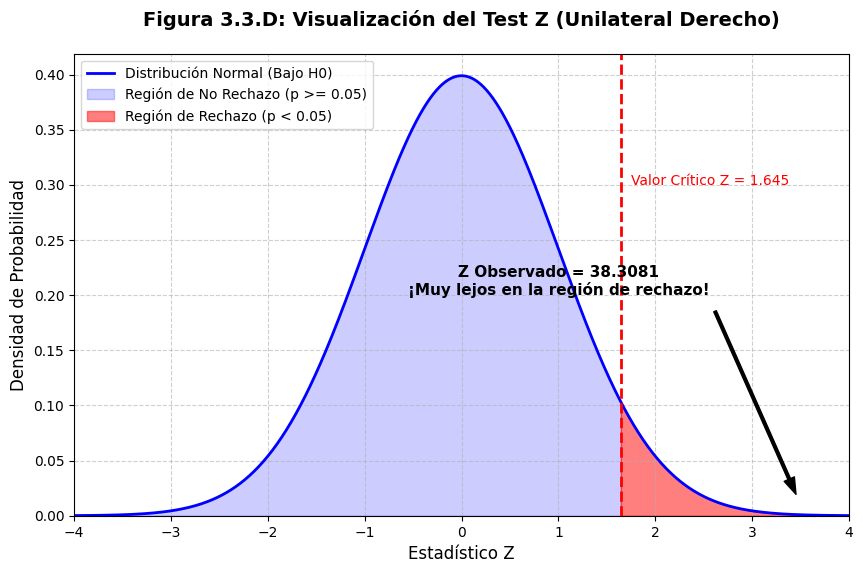

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Definir los parámetros ---
alpha = 0.05
z_critico = norm.ppf(1 - alpha)  # -> 1.645
z_observado = 38.3081

# --- 2. Crear la Curva Normal Estándar ---
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Distribución Normal (Bajo H0)')

# --- 3. Sombrear la Región de No Rechazo ---
x_no_rechazo = np.linspace(-4, z_critico, 1000)
y_no_rechazo = norm.pdf(x_no_rechazo, 0, 1)
plt.fill_between(x_no_rechazo, 0, y_no_rechazo, color='blue', alpha=0.2, 
                 label=f'Región de No Rechazo (p >= {alpha})')

# --- 4. Sombrear la Región de Rechazo ---
x_rechazo = np.linspace(z_critico, 4, 1000)
y_rechazo = norm.pdf(x_rechazo, 0, 1)
plt.fill_between(x_rechazo, 0, y_rechazo, color='red', alpha=0.5, 
                 label=f'Región de Rechazo (p < {alpha})')

# --- 5. Anotar los puntos clave ---

# Valor Crítico
plt.axvline(z_critico, color='red', linestyle='--', linewidth=2)
plt.text(z_critico + 0.1, 0.3, f'Valor Crítico Z = {z_critico:.3f}', 
         color='red', ha='left')

# Estadístico Z Observado (Anotación)
# Dado que 38.31 está fuera del gráfico, usamos una flecha
plt.annotate(
    f'Z Observado = {z_observado}\n¡Muy lejos en la región de rechazo!',
    xy=(3.5, 0.01),  # Dónde apunta la flecha (extremo del gráfico)
    xytext=(1, 0.2),  # Dónde está el texto
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
    ha='center'
)

# --- 6. Formato del Gráfico ---
plt.title('Figura 3.3.D: Visualización del Test Z (Unilateral Derecho)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Estadístico Z', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper left')
plt.grid(linestyle='--', alpha=0.6)
plt.ylim(bottom=0)
plt.xlim(-4, 4) # Forzamos la vista estándar

plt.show()